# How to work with tetrahedral meshes

This notebook demonstrates how to:
1. Load a tetrahedral mesh
2. Compute the Laplacian and its spectrum
3. Compute functional maps between tetrahedral meshes

In [3]:
import gsops.backend as gs

from geomfum.dataset.notebook import NotebooksDataset
from geomfum.laplacian import LaplacianSpectrumFinder, TetrahedralLaplacianFinder
from geomfum.numerics.eig import ScipyEigsh
from geomfum.shape import TetrahedralMesh

## 1. Load tetrahedral meshes

Load `.mesh` files (Medit format). Other volumetric formats supported by meshio also work (`.vtk`, `.vtu`, etc.).

In [4]:
dataset = NotebooksDataset()
tetrahedral_a = TetrahedralMesh.from_file(
    dataset.get_filename("volumetric_armadillo_01")
)
tetrahedral_b = TetrahedralMesh.from_file(
    dataset.get_filename("volumetric_armadillo_02")
)

print(f"Mesh A: {tetrahedral_a.n_vertices} vertices, {tetrahedral_a.n_tets} tetrahedra")
print(f"Mesh B: {tetrahedral_b.n_vertices} vertices, {tetrahedral_b.n_tets} tetrahedra")

Mesh A: 27211 vertices, 104900 tetrahedra
Mesh B: 27211 vertices, 104900 tetrahedra


## 2. Inspect mesh properties

Tetrahedral meshes provide lazy-cached properties for volumes, vertex masses, edges, etc.

In [5]:
print(f"Tet volumes shape: {tetrahedral_a.tet_volumes.shape}")
print(f"Vertex areas (masses) shape: {tetrahedral_a.vertex_areas.shape}")
print(f"Edges shape: {tetrahedral_a.edges.shape}")
print(f"Tet faces shape: {tetrahedral_a.tet_faces.shape}")

Tet volumes shape: (104900,)
Vertex areas (masses) shape: (27211,)
Edges shape: (151253, 2)
Tet faces shape: (104900, 4, 3)


## 3. Compute the tetrahedral Laplacian

The `TetrahedralLaplacianFinder` uses dihedral angle cotangent weights.

In [6]:
laplacian_finder = TetrahedralLaplacianFinder()

stiffness_matrix, mass_matrix = laplacian_finder(tetrahedral_a)

print(f"Stiffness matrix shape: {stiffness_matrix.shape}")
print(f"Mass matrix shape: {mass_matrix.shape}")

Stiffness matrix shape: (27211, 27211)
Mass matrix shape: (27211, 27211)


## 4. Compute Laplacian spectrum

Compute eigenvalues and eigenvectors of the Laplacian, and set them as the basis for the shape.

In [7]:
spectrum_size = 20

spectrum_finder = LaplacianSpectrumFinder(
    nonzero=False,
    fix_sign=False,
    laplacian_finder=TetrahedralLaplacianFinder(),
    eig_solver=ScipyEigsh(spectrum_size=spectrum_size, sigma=-0.01),
)

tetrahedral_a.laplacian.find_spectrum(
    spectrum_size=spectrum_size,
    laplacian_spectrum_finder=spectrum_finder,
    set_as_basis=True,
)
tetrahedral_b.laplacian.find_spectrum(
    spectrum_size=spectrum_size,
    laplacian_spectrum_finder=spectrum_finder,
    set_as_basis=True,
)

# Use first 20 eigenfunctions for functional maps
tetrahedral_a.basis.use_k = 20
tetrahedral_b.basis.use_k = 20

print(f"Eigenvalues (first 10): {tetrahedral_a.basis.vals[:10]}")

Eigenvalues (first 10): [1.23180979e-13 2.73724606e+00 3.09833367e+00 4.82030632e+00
 6.26522458e+00 1.16336107e+01 1.97994185e+01 2.06098298e+01
 2.43025280e+01 3.18897745e+01]


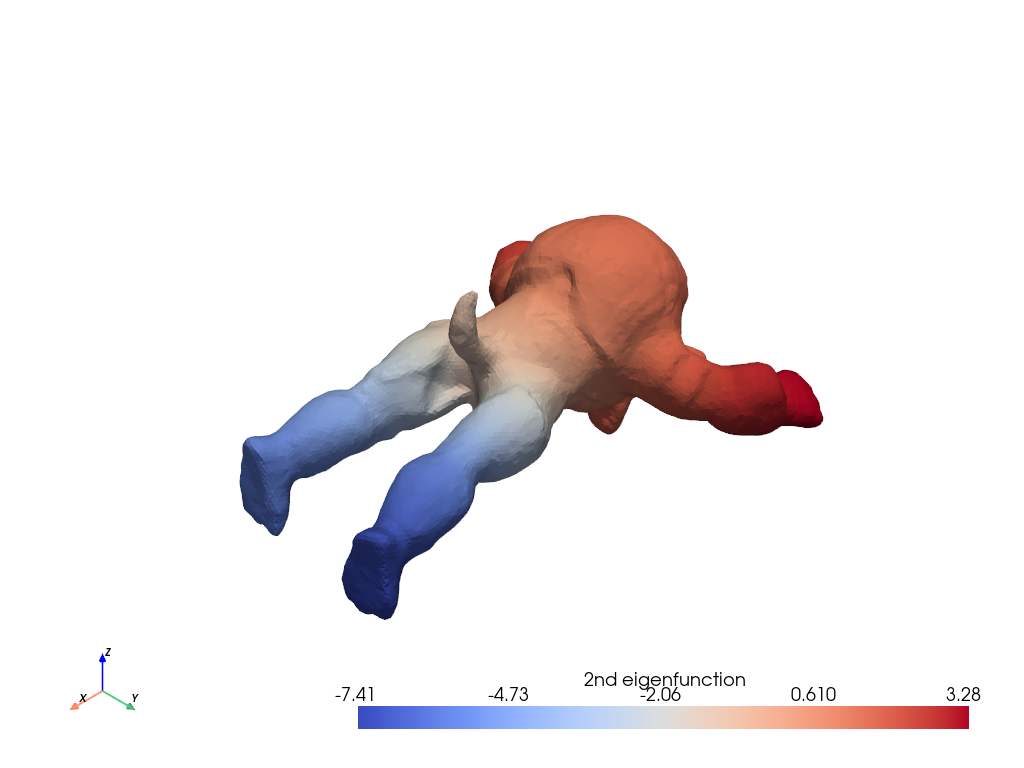

In [ ]:
import sys
from pathlib import Path

import geomfum

notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
notebooks_dir_str = str(notebooks_dir)
if notebooks_dir_str not in sys.path:
    sys.path.insert(0, notebooks_dir_str)

from plot_utils import setup_pyvista, show_volume_mesh  # noqa: E402

setup_pyvista()
show_volume_mesh(
    tetrahedral_a.vertices,
    tetrahedral_a.tets,
    scalars=tetrahedral_a.basis.vecs[:, 1],
    scalar_name="2nd eigenfunction",
    cmap="coolwarm",
)

## 5. Compute ground truth functional map from identity correspondence

When the two meshes have the same connectivity (identity correspondence), we can compute the ground truth functional map.

In [9]:
from geomfum.convert import FmFromP2pConverter

p2p21 = gs.arange(tetrahedral_a.n_vertices)
converter = FmFromP2pConverter()
fmap12 = converter(p2p21, tetrahedral_b.basis, tetrahedral_a.basis)

print(f"Functional map shape: {fmap12.shape}")

Functional map shape: (20, 20)


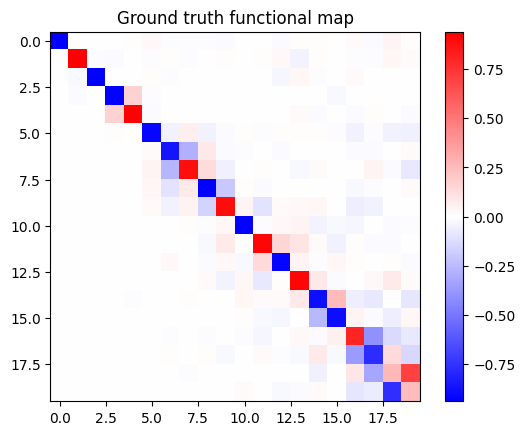

In [10]:
import matplotlib.pyplot as plt

plt.imshow(fmap12, cmap="bwr")
plt.colorbar()
plt.title("Ground truth functional map")
plt.show()

## 6. Estimate functional map from optimization

Use spectral descriptors and optimization to estimate the functional map.

In [11]:
import numpy as np

from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import (
    LandmarkWaveKernelSignature,
    WaveKernelSignature,
)
from geomfum.functional_map import (
    FactorSum,
    LBCommutativityEnforcing,
    OperatorCommutativityEnforcing,
    SpectralDescriptorPreservation,
)
from geomfum.numerics.optimization import ScipyMinimize

In [12]:
# Set random landmarks
n_vertices = tetrahedral_a.n_vertices
samples = np.random.randint(n_vertices, size=10)

tetrahedral_a.landmark_indices = samples
tetrahedral_b.landmark_indices = samples

In [13]:
# Build descriptor pipeline
steps = [
    WaveKernelSignature(n_domain=200, k=20),
    LandmarkWaveKernelSignature(n_domain=200, k=20),
    ArangeSubsampler(10),
    L2InnerNormalizer(),
]

pipeline = DescriptorPipeline(steps)

descr_a = pipeline.apply(tetrahedral_a)
descr_b = pipeline.apply(tetrahedral_b)

print(f"Descriptor A shape: {descr_a.shape}")
print(f"Descriptor B shape: {descr_b.shape}")

Descriptor A shape: (220, 27211)
Descriptor B shape: (220, 27211)


In [14]:
# Define optimization factors
factors = [
    SpectralDescriptorPreservation(
        tetrahedral_a.basis.project(descr_a),
        tetrahedral_b.basis.project(descr_b),
        weight=1.0,
    ),
    LBCommutativityEnforcing.from_bases(
        tetrahedral_a.basis,
        tetrahedral_b.basis,
        weight=1e-2,
    ),
    OperatorCommutativityEnforcing.from_multiplication(
        tetrahedral_a.basis, descr_a, tetrahedral_b.basis, descr_b, weight=1e-1
    ),
]

objective = FactorSum(factors)

In [15]:
# Optimize
optimizer = ScipyMinimize(method="L-BFGS-B")

x0 = gs.eye(tetrahedral_b.basis.spectrum_size)

res = optimizer.minimize(
    objective,
    x0,
    fun_jac=objective.gradient,
)

fmap = res.x.reshape(x0.shape)
print(f"Estimated functional map shape: {fmap.shape}")

Estimated functional map shape: (20, 20)


In [16]:
# Refine with ICP
from geomfum.refine import IcpRefiner

icp = IcpRefiner()
icp_fmap = icp(fmap, tetrahedral_a.basis, tetrahedral_b.basis)

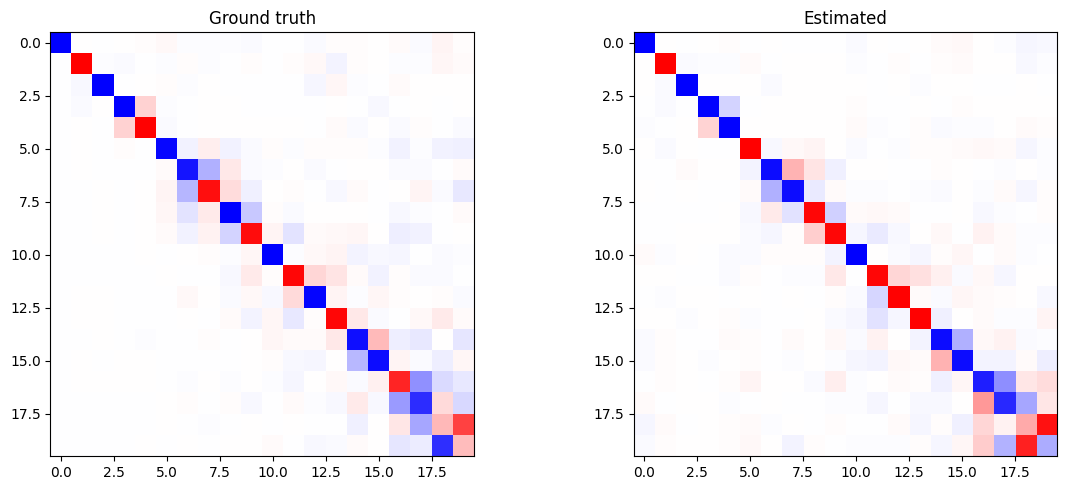

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(fmap12, cmap="bwr")
axes[0].set_title("Ground truth")

axes[1].imshow(icp_fmap, cmap="bwr")
axes[1].set_title("Estimated")

plt.tight_layout()
plt.show()